In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Funções auxiliares
# ==============================

def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise Exception("Erro ao carregar imagem")
    return img

def normalize(img):
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

def show(images, titles, cols=3):
    plt.figure(figsize=(12, 8))
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(len(images)//cols + 1, cols, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

    # ==============================
# Gradiente da Gaussiana
# ==============================

def grad_gauss(img, ksize=5, sigma=1.0):
    blur = cv2.GaussianBlur(img, (ksize, ksize), sigma)

    gx = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=ksize)
    gy = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=ksize)

    mag = np.sqrt(gx**2 + gy**2)
    return normalize(mag)

# ==============================
# Laplaciano da Gaussiana
# ==============================

def log_filter_raw(img, ksize=5, sigma=2.0):
    blur = cv2.GaussianBlur(img, (ksize, ksize), sigma)
    lap = cv2.Laplacian(blur, cv2.CV_64F)
    return lap


# ==============================
# Zero-crossing (para LoG)
# ==============================

def zero_crossing(img):
    zc = np.zeros_like(img)

    for i in range(1, img.shape[0]-1):
        for j in range(1, img.shape[1]-1):
            patch = img[i-1:i+2, j-1:j+2]
            if patch.max() > 0 and patch.min() < 0:
                zc[i, j] = 255

    return zc



Exemplos do gaussiano e laplaciano com e sem suavização

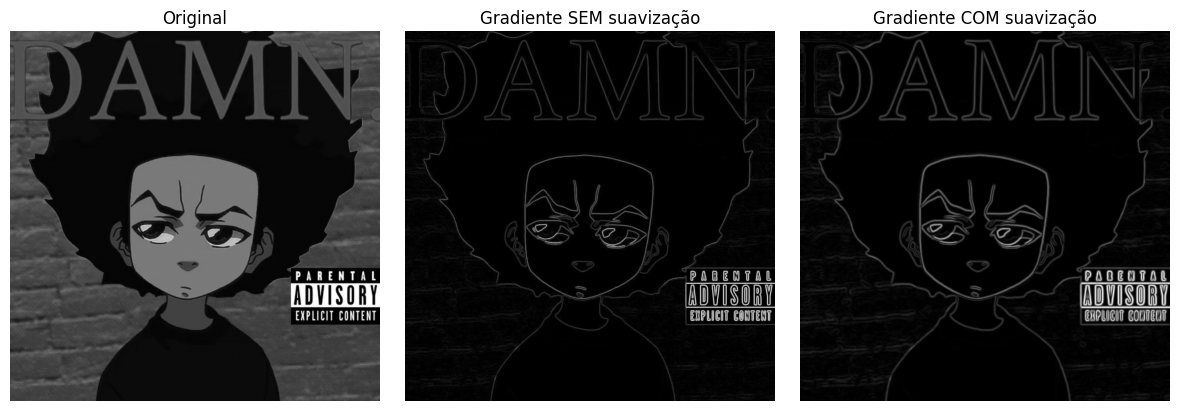

In [4]:
# ==============================
# MAIN
# ==============================

img = load_image("../img/damnboondocks.jpg")

# =========================================================
# 1) Gradiente da Gaussiana SEM e COM suavização
# =========================================================

# Sem suavização (gradiente direto)
gx = cv2.Sobel(img, cv2.CV_64F, 1, 0)
gy = cv2.Sobel(img, cv2.CV_64F, 0, 1)
grad_sem = normalize(np.sqrt(gx**2 + gy**2))

# Com suavização
grad_com = grad_gauss(img, sigma=1.0)

show(
    [img, grad_sem, grad_com],
    ["Original", "Gradiente SEM suavização", "Gradiente COM suavização"]
)



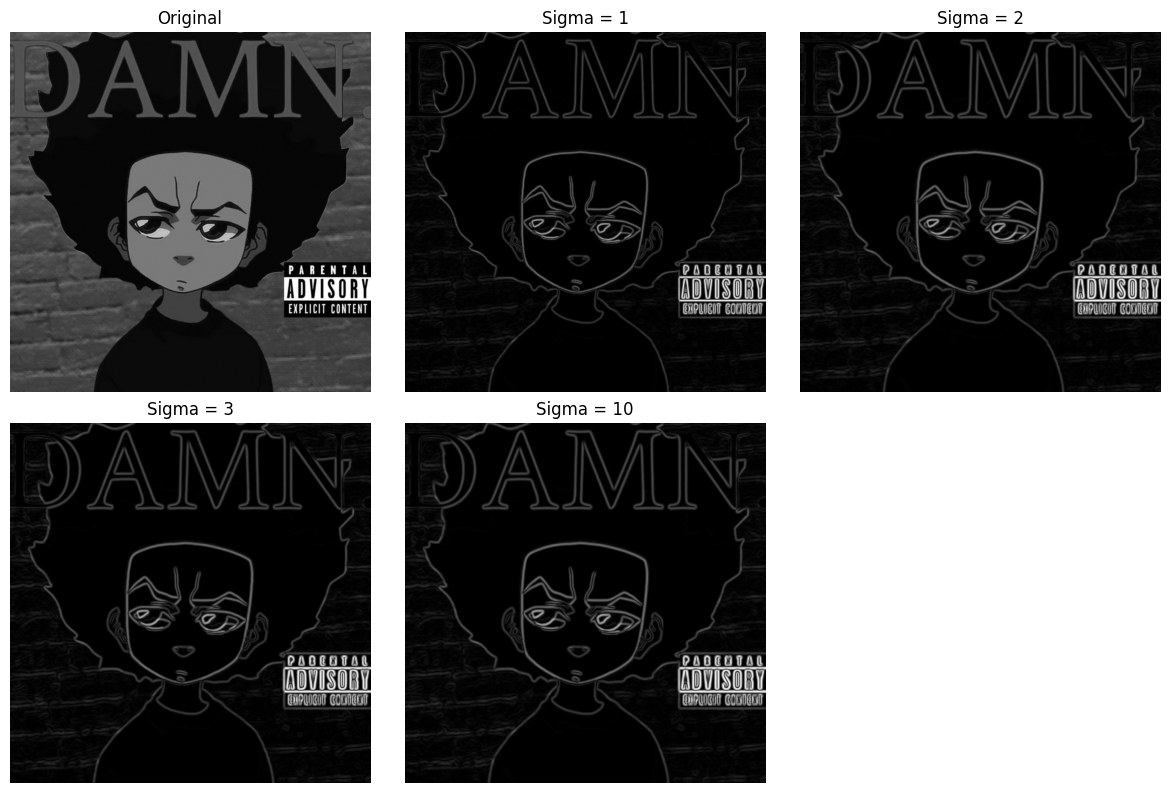

In [5]:
# =========================================================
# 2) Gradiente da Gaussiana variando sigma
# =========================================================

sigmas = [1, 2, 3, 10]
images = [img]
titles = ["Original"]

for s in sigmas:
    g = grad_gauss(img, sigma=s)
    images.append(g)
    titles.append(f"Sigma = {s}")

show(images, titles)



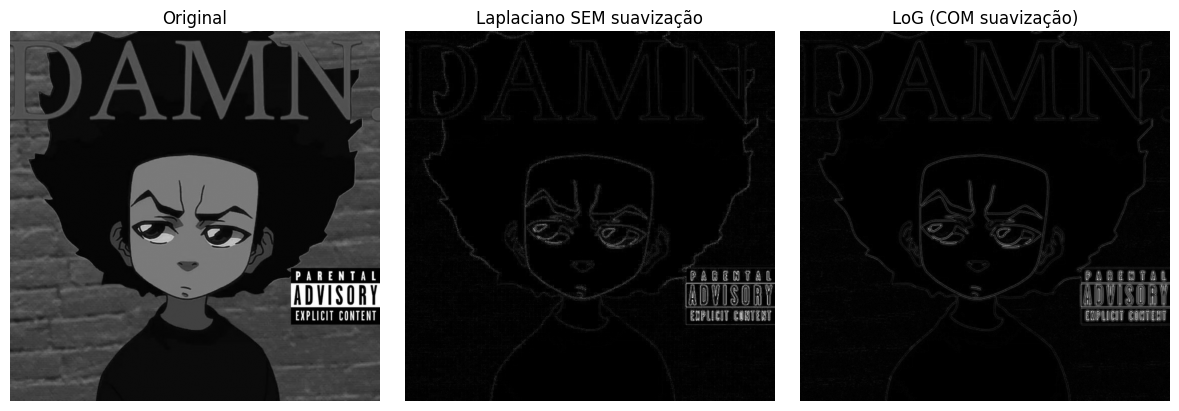

In [6]:
# =========================================================
# 3) Laplaciano da Gaussiana SEM e COM suavização
# =========================================================

# Sem suavização
lap_sem = cv2.Laplacian(img, cv2.CV_64F)
lap_sem_abs = cv2.convertScaleAbs(lap_sem)

# Com suavização
blur = cv2.GaussianBlur(img, (5,5), 1.0)
lap_com = cv2.Laplacian(blur, cv2.CV_64F)
lap_com_abs = np.abs(lap_com)


show(
    [img, lap_sem_abs, lap_com_abs],
    ["Original", "Laplaciano SEM suavização", "LoG (COM suavização)"]
)



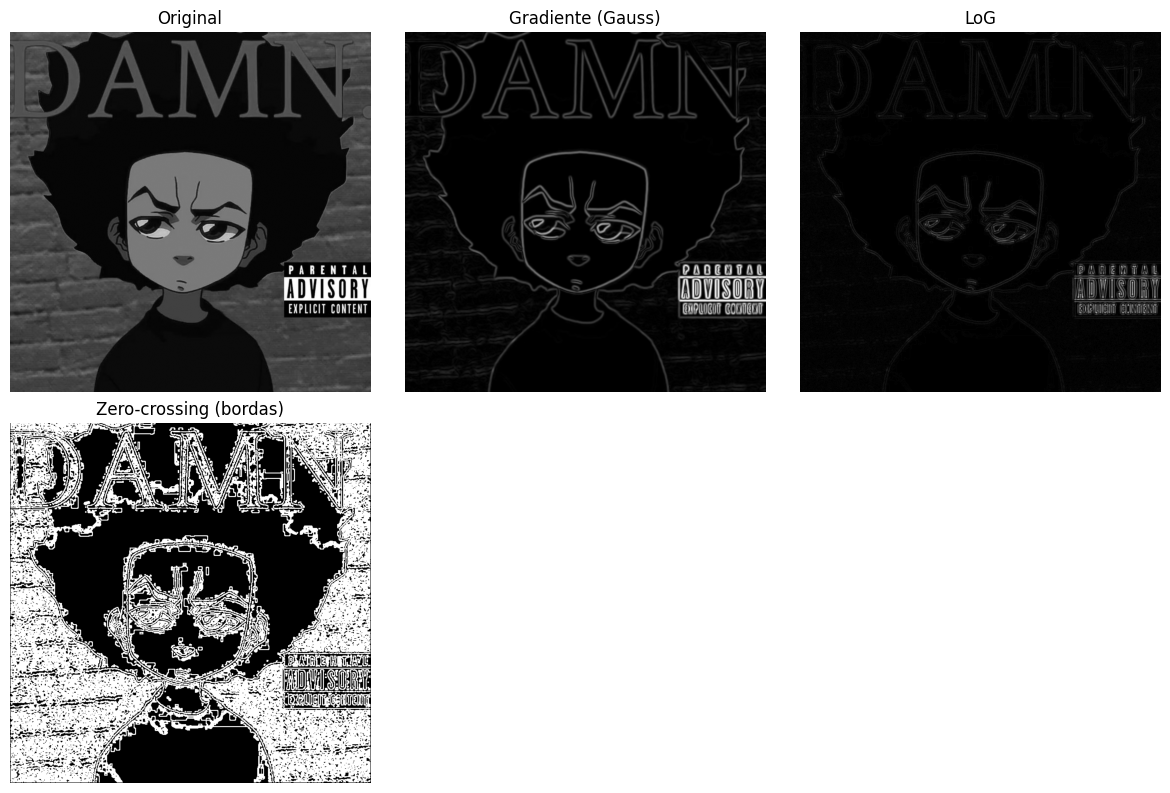

In [7]:
# =========================================================
# 4) Gradiente + Laplaciano da Gaussiana com suavização
# =========================================================

grad = grad_gauss(img, sigma=2.0)
log_raw = log_filter_raw(img, sigma=2.0)

# Zero-crossing do LoG
zc = zero_crossing(log_raw)

# Para visualização do LoG, normalizamos valores absolutos
log_vis = cv2.convertScaleAbs(log_raw)


show(
    [img, grad, log_vis, zc],
    ["Original", "Gradiente (Gauss)", "LoG", "Zero-crossing (bordas)"]
)

Exemplo 2: visualização do campo de gradientes de uma imagem

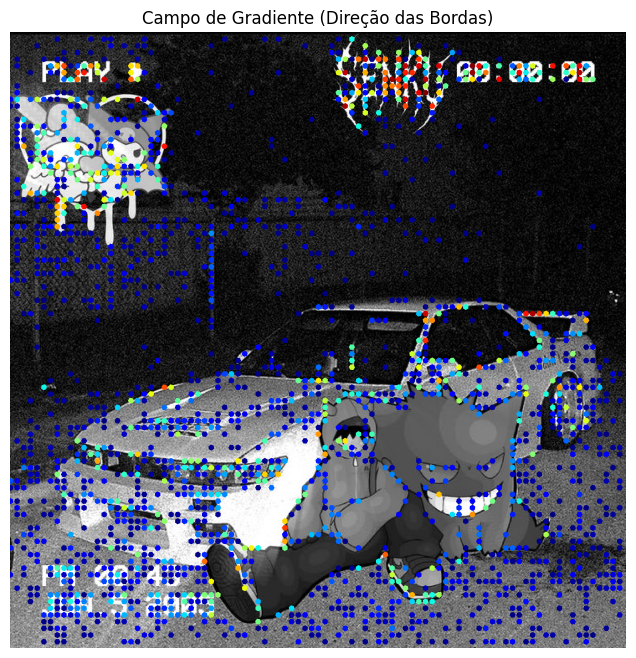

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Carregar imagem (ajuste o caminho se necessário)
imagem = cv2.imread('../img/gengarjdm.jpg', cv2.IMREAD_GRAYSCALE)

if imagem is None:
    raise Exception("Erro ao carregar a imagem")

# Normalizar (melhora estabilidade dos gradientes)
imagem = np.float32(imagem) / 255.0

# Calcular gradientes (Sobel)
grad_x = cv2.Sobel(imagem, cv2.CV_64F, 1, 0, ksize=3)
grad_y = cv2.Sobel(imagem, cv2.CV_64F, 0, 1, ksize=3)

# Magnitude do gradiente
magnitude = np.sqrt(grad_x**2 + grad_y**2)

# 🔽 Reduzir densidade dos vetores (ESSENCIAL para essa imagem)
step = 8
y, x = np.mgrid[0:imagem.shape[0]:step, 0:imagem.shape[1]:step]

u = grad_x[::step, ::step]
v = grad_y[::step, ::step]
mag = magnitude[::step, ::step]

# 🔽 Filtrar apenas bordas relevantes (evita poluição)
threshold = 0.5
mask = mag > threshold

# Plot
plt.figure(figsize=(8, 8))
plt.imshow(imagem, cmap='gray')

plt.quiver(
    x[mask], y[mask],
    u[mask], v[mask],
    mag[mask],
    cmap='jet',
    angles='xy',
    scale_units='xy',
    scale=30,   # ajuste fino aqui
    width=0.01
)

plt.title("Campo de Gradiente (Direção das Bordas)")
plt.axis('off')
plt.show()

Exemplo 3: Comparação entre Sobel e Prewitt

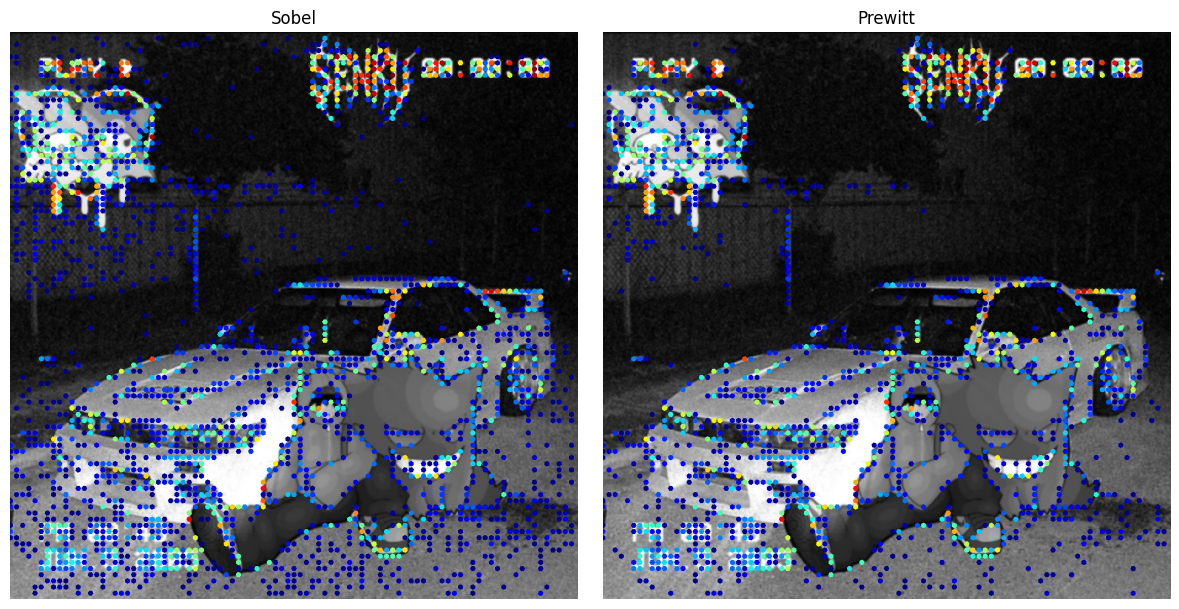

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Carregar imagem
imagem = cv2.imread('../img/gengarjdm.jpg', cv2.IMREAD_GRAYSCALE)

if imagem is None:
    raise Exception("Erro ao carregar a imagem")

# Normalizar
imagem = np.float32(imagem) / 255.0

# Suavização (opcional, melhora resultado)
imagem = cv2.GaussianBlur(imagem, (5, 5), 1)

# =========================
# SOBEL
# =========================
sobel_x = cv2.Sobel(imagem, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(imagem, cv2.CV_64F, 0, 1, ksize=3)
mag_sobel = np.sqrt(sobel_x**2 + sobel_y**2)

# =========================
# PREWITT (manual)
# =========================
kernel_px = np.array([[-1, 0, 1],
                      [-1, 0, 1],
                      [-1, 0, 1]], dtype=np.float32)

kernel_py = np.array([[ 1,  1,  1],
                      [ 0,  0,  0],
                      [-1, -1, -1]], dtype=np.float32)

prewitt_x = cv2.filter2D(imagem, -1, kernel_px)
prewitt_y = cv2.filter2D(imagem, -1, kernel_py)
mag_prewitt = np.sqrt(prewitt_x**2 + prewitt_y**2)

# =========================
# AMOSTRAGEM
# =========================
step = 8
y, x = np.mgrid[0:imagem.shape[0]:step, 0:imagem.shape[1]:step]

# Sobel
u_s = sobel_x[::step, ::step]
v_s = sobel_y[::step, ::step]
m_s = mag_sobel[::step, ::step]

# Prewitt
u_p = prewitt_x[::step, ::step]
v_p = prewitt_y[::step, ::step]
m_p = mag_prewitt[::step, ::step]

# Threshold (bordas relevantes)
th = 0.2
mask_s = m_s > th
mask_p = m_p > th

# =========================
# PLOT
# =========================
plt.figure(figsize=(12, 6))

# Sobel
plt.subplot(1, 2, 1)
plt.imshow(imagem, cmap='gray')
plt.quiver(x[mask_s], y[mask_s], u_s[mask_s], v_s[mask_s],
           m_s[mask_s], cmap='jet',
           angles='xy', scale_units='xy', scale=30, width=0.01)
plt.title("Sobel")
plt.axis('off')

# Prewitt
plt.subplot(1, 2, 2)
plt.imshow(imagem, cmap='gray')
plt.quiver(x[mask_p], y[mask_p], u_p[mask_p], v_p[mask_p],
           m_p[mask_p], cmap='jet',
           angles='xy', scale_units='xy', scale=30, width=0.01)
plt.title("Prewitt")
plt.axis('off')

plt.tight_layout()
plt.show()

## Uso de descritores: SIFT, Harris Corner Detector & ORB

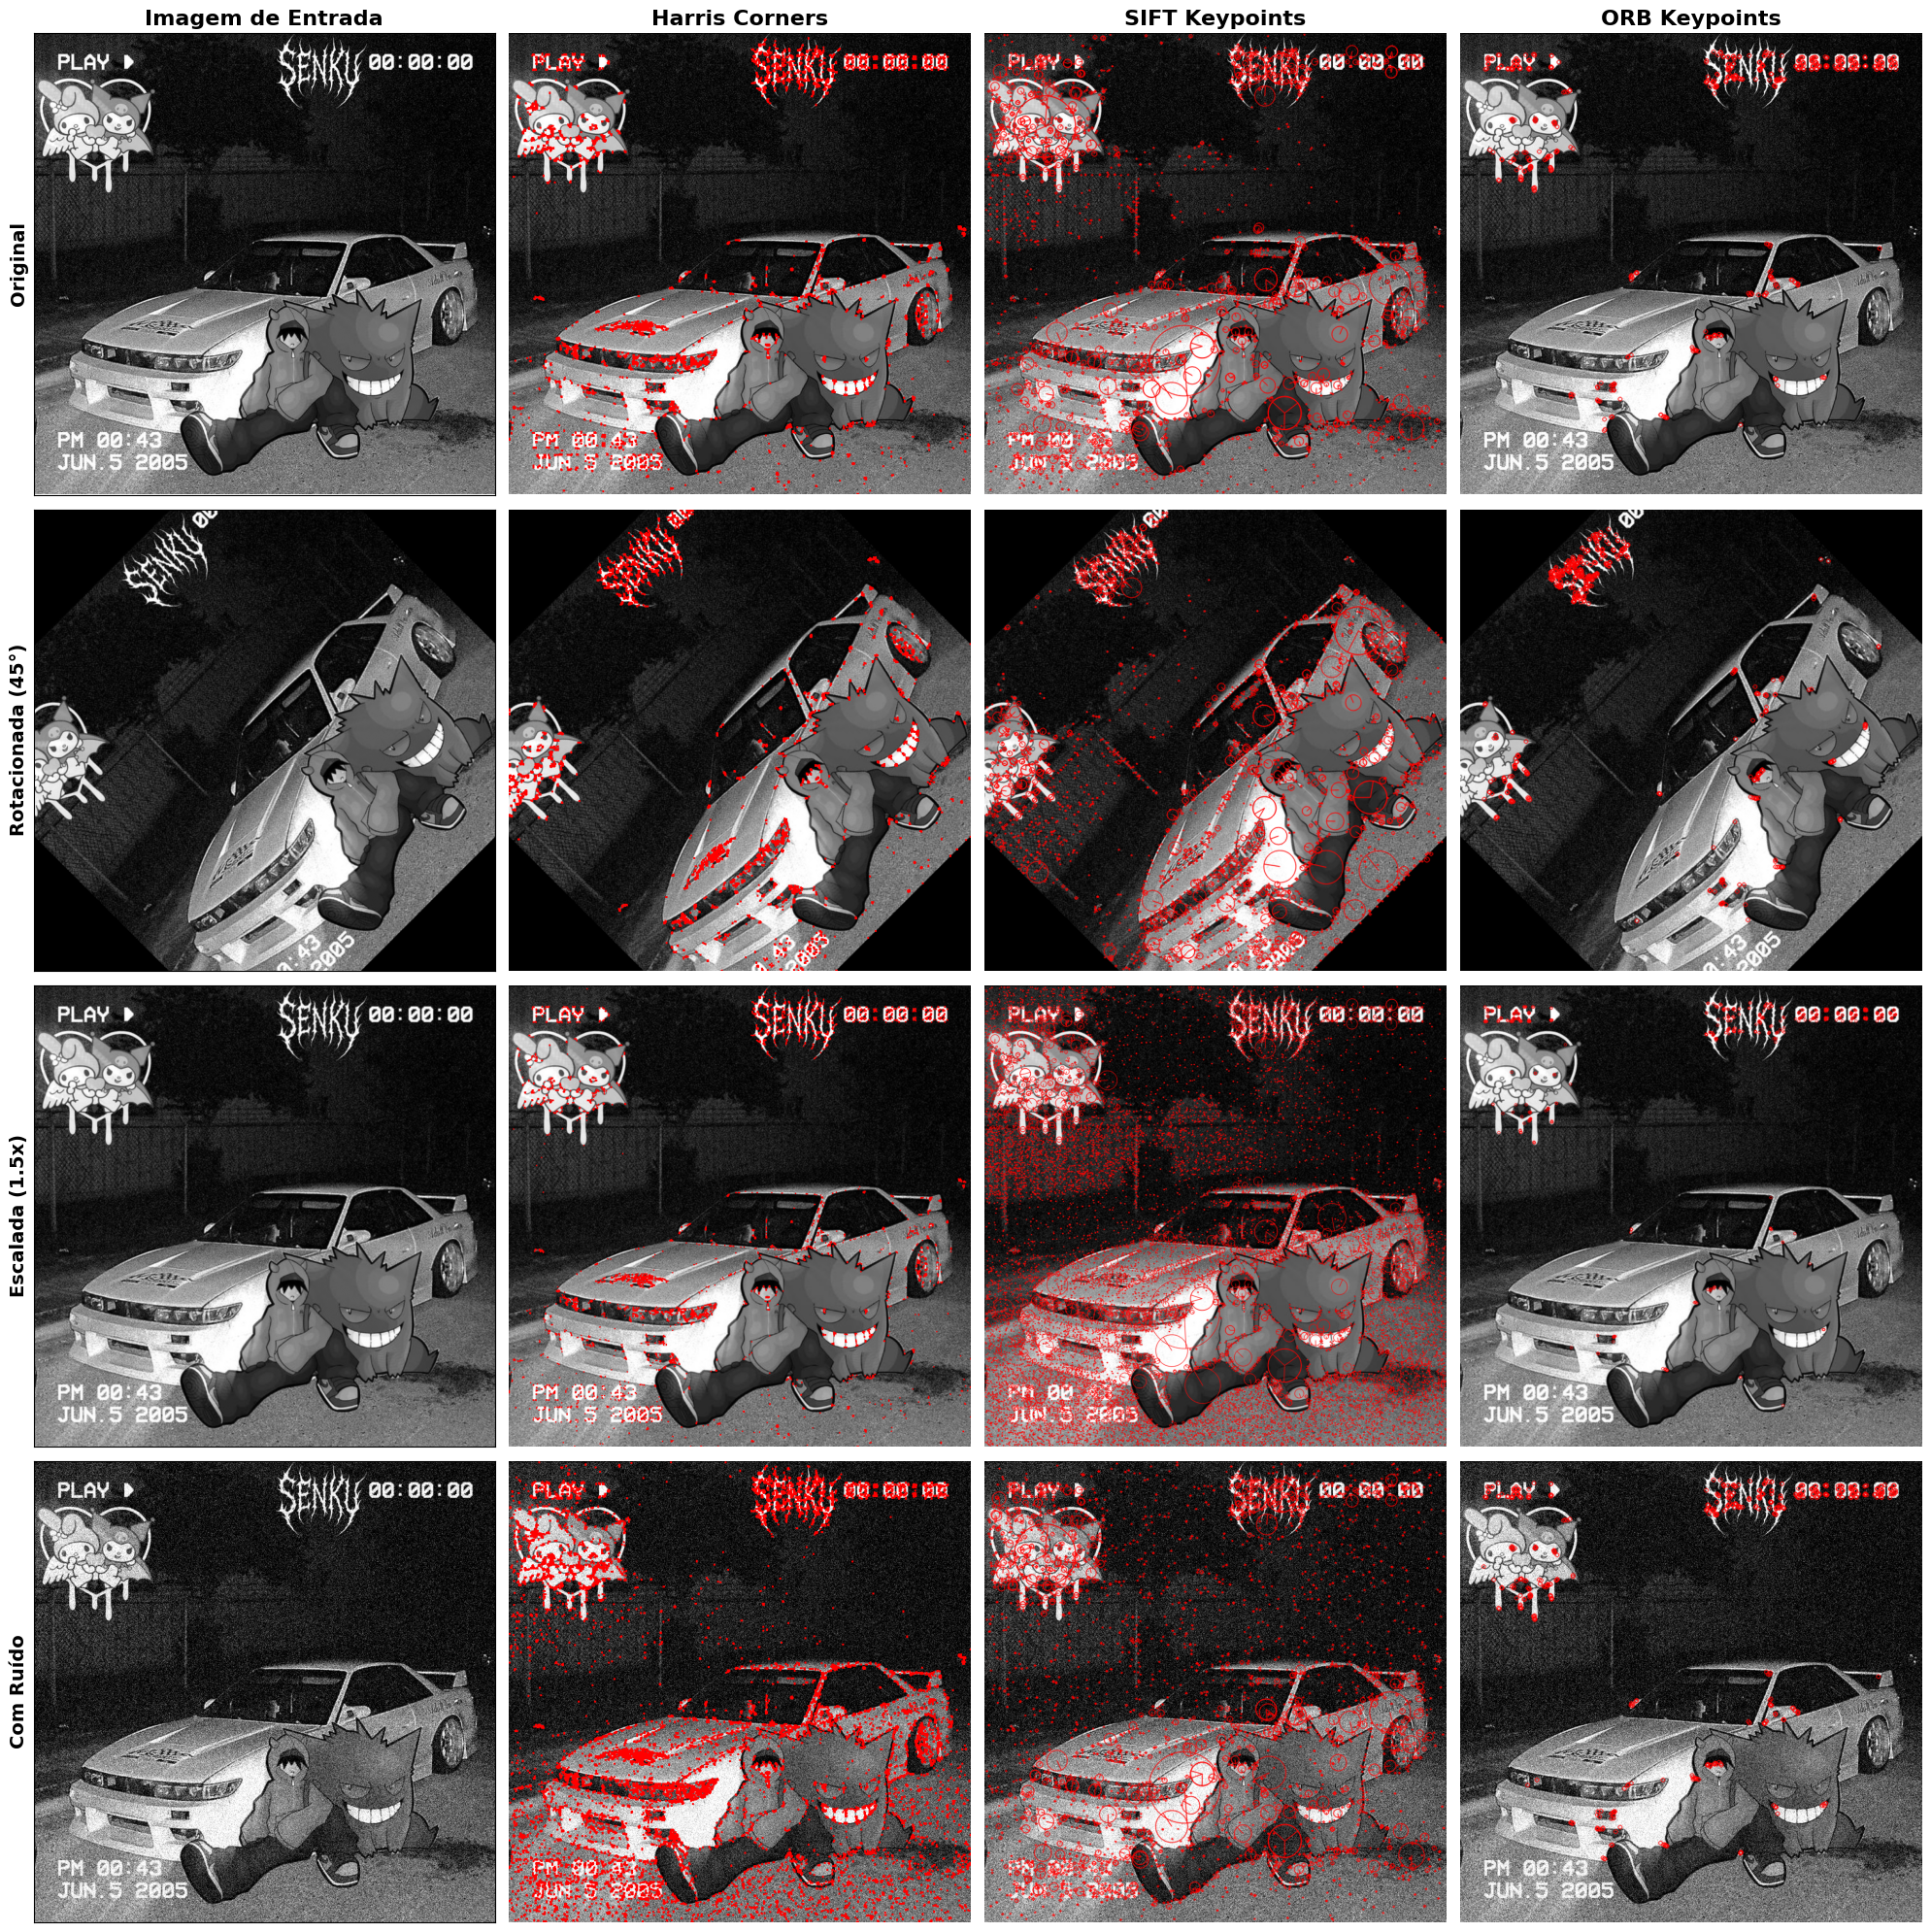

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Baixar uma imagem de exemplo caso não exista
image_path = "../img/gengarjdm.jpg"

# 1. Carregar imagem original em escala de cinza
img_orig = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if img_orig is None:
    raise ValueError("Imagem não encontrada. Verifique o caminho ou o download.")

# Funções auxiliares para transformações e ruído
def rotate_image(image, angle):
    h, w = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(image, M, (w, h))

def scale_image(image, scale):
    h, w = image.shape[:2]
    return cv2.resize(image, (int(w * scale), int(h * scale)))

def add_noise(image, std_dev=25):
    noise = np.random.normal(0, std_dev, image.shape)
    noisy_image = np.clip(image.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return noisy_image

# Imagens de teste
img_rot = rotate_image(img_orig, 45)
img_scale = scale_image(img_orig, 1.5)
img_noise = add_noise(img_orig, 30)

images_to_test = {
    "Original": img_orig,
    "Rotacionada (45°)": img_rot,
    "Escalada (1.5x)": img_scale,
    "Com Ruído": img_noise
}

# Inicializar detectores SIFT e ORB
sift = cv2.SIFT_create()
orb = cv2.ORB_create()

def apply_detectors(img):
    # ==========================
    # 1. Harris Corner Detector
    # ==========================
    harris_resp = cv2.cornerHarris(np.float32(img), 2, 3, 0.04)
    harris_resp = cv2.dilate(harris_resp, None)
    img_harris = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    # Destaque em vermelho para Harris
    img_harris[harris_resp > 0.01 * harris_resp.max()] = [255, 0, 0] 
    qty_harris = np.sum(harris_resp > 0.01 * harris_resp.max())
    
    # ==========================
    # 2. SIFT
    # ==========================
    kp_sift, _ = sift.detectAndCompute(img, None)
    img_sift = cv2.drawKeypoints(img, kp_sift, None, color=(255, 0, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    qty_sift = len(kp_sift)
    
    # ==========================
    # 3. ORB
    # ==========================
    kp_orb, _ = orb.detectAndCompute(img, None)
    img_orb = cv2.drawKeypoints(img, kp_orb, None, color=(255, 0, 0), flags=0)
    qty_orb = len(kp_orb)
    
    return img_harris, img_sift, img_orb, qty_harris, qty_sift, qty_orb

# Plotando os resultados comparativos
fig, axes = plt.subplots(4, 4, figsize=(20, 20))

col_titles = ["Imagem de Entrada", "Harris Corners", "SIFT Keypoints", "ORB Keypoints"]
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=16, fontweight='bold')

for i, (name, img) in enumerate(images_to_test.items()):
    img_harris, img_sift, img_orb, q_h, q_s, q_o = apply_detectors(img)
    
    # Plot Input
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_ylabel(name, fontsize=14, fontweight='bold')
    axes[i, 0].set_xticks([])
    axes[i, 0].set_yticks([])
    
    # Plot Harris
    axes[i, 1].imshow(img_harris)
    axes[i, 1].axis('off')
    
    # Plot SIFT
    axes[i, 2].imshow(img_sift)
    axes[i, 2].axis('off')
    
    # Plot ORB
    axes[i, 3].imshow(img_orb)
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()

## Resumo e Observações: Harris, SIFT e ORB

### O que cada um faz (e o que cada um entrega)

| Descritor | Detecta | Gera descritor? | Invariante a... |
|-----------|---------|-----------------|-----------------|
| **Harris** | Cantos (corners) | Não | Rotação (parcial) |
| **SIFT**   | Blobs/regiões de contraste em múltiplas escalas | Sim (128-dim, float) | Rotação, escala, iluminação |
| **ORB**    | Cantos (FAST) + orienta com BRIEF | Sim (256-bits, binário) | Rotação, ruído leve |

---

### Harris Corner Detector
- Detecta pontos onde há variação de intensidade em **duas direções** — ou seja, cantos reais, não só bordas.
- **Não é invariante a escala**: se a imagem for redimensionada, ele pode detectar pontos diferentes.
- Não gera um vetor descritor — só localiza onde há cantos. Para fazer matching, precisaria de um descritor adicional.
- O threshold `0.01 * harris_resp.max()` controla a sensibilidade. Valores menores = mais pontos, mais ruído.

### SIFT (Scale-Invariant Feature Transform)
- Detecta e **descreve** keypoints usando pirâmide de escalas (DoG — Difference of Gaussians).
- Invariante a escala e rotação, e razoavelmente robusto a mudanças de iluminação.
- O descritor é um vetor de 128 floats — preciso, mas pesado.
- É o mais robusto dos três para imagens rotacionadas e escaladas, como pode ser observado na comparação acima.
- **Ponto negativo**: mais lento e patenteado (embora disponível no OpenCV com flag `nonfree`).

### ORB (Oriented FAST and Rotated BRIEF)
- Combina o detector **FAST** (rápido, detecta cantos) com o descritor **BRIEF** orientado (binário).
- O descritor binário torna o matching muito mais rápido (distância de Hamming vs. distância euclidiana do SIFT).
- Bom desempenho em tempo real; menos preciso que SIFT em rotações grandes ou mudanças de escala acentuadas.
- Por padrão, detecta até 500 keypoints (`ORB_create(500)`) — esse limite pode ser ajustado.

---

### O que se observa na comparação acima

- **Imagem rotacionada**: SIFT mantém a quantidade e qualidade dos keypoints; Harris e ORB são mais afetados.
- **Imagem escalada**: SIFT adapta bem pela pirâmide de escalas; Harris perde ou ganha cantos dependendo do novo tamanho.
- **Imagem com ruído**: todos degradam, mas SIFT costuma ser mais estável por suavizar implicitamente na construção do DoG.

### Quando usar cada um

- **Harris** para detectar cantos de forma simples, sem precisar de matching entre imagens.
- **SIFT** quando a qualidade do matching for prioritária e o custo computacional for aceitável (ex: reconstrução 3D, panoramas).
- **ORB** quando precisar de velocidade (aplicações em tempo real, dispositivos embarcados) e a variação de escala for pequena.